# Bolus Timing Transformer — LOSO Sweep (cleaned up)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score


## Signal definitions

In [ ]:
xml_signals = ["glucose_level", "basis_heart_rate", "basis_gsr",
               "basis_skin_temperature", "basis_air_temperature"]
signals = ["glucose_level", "basis_heart_rate", "basis_gsr",
           "basis_skin_temperature", "basis_air_temperature",
           "running_IOB", "self_reported_carbs", "sin_t", "cos_t"]
signals_for_loss = ["glucose_level", "basis_heart_rate", "basis_gsr",
                     "basis_skin_temperature", "basis_air_temperature"]

start_time = pd.Timestamp('2020-06-01 10:00:00')


## Data loading and alignment

In [ ]:
def get_bolus_df(subject_num, split):
    bolus_df = pd.read_xml(f'bolus_data/{subject_num}-ws-{split}.xml', xpath="./bolus/event")
    bolus_df["date_time"] = pd.to_datetime(bolus_df['ts_begin'], format='%d-%m-%Y %H:%M:%S')
    bolus_df['running_minutes'] = (bolus_df['date_time'] - start_time).dt.total_seconds() / 60
    bolus_df = bolus_df.sort_values('running_minutes').reset_index(drop=True)
    return bolus_df


In [ ]:
def load_data(subject_num, split):
    bolus_df = get_bolus_df(subject_num, split)

    # load each signal separately
    signal_dfs = {}
    for signal in xml_signals:
        sig_df = pd.read_xml(f'bolus_data/{subject_num}-ws-{split}.xml', xpath=f"./{signal}/event")
        sig_df['date_time'] = pd.to_datetime(sig_df['ts'], format='%d-%m-%Y %H:%M:%S')
        sig_df = sig_df[['date_time', 'value']].rename(columns={'value': signal})
        signal_dfs[signal] = sig_df.sort_values('date_time').reset_index(drop=True)

    # align all signals onto the glucose (5-min) grid
    df = signal_dfs['glucose_level']
    for signal in xml_signals[1:]:
        df = pd.merge_asof(
            df, signal_dfs[signal],
            on='date_time',
            direction='backward',
            tolerance=pd.Timedelta('2.5min')
        )

    df["minutes"] = (df["date_time"] - start_time).dt.total_seconds() / 60
    df["running_IOB"] = 0.0
    df["self_reported_carbs"] = 0.0

    # trim to the window where the wearable signals actually have coverage
    overlap_start = max(df.loc[df[col].notna(), 'date_time'].min()
                     for col in ['basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature'])
    overlap_end = min(df.loc[df[col].notna(), 'date_time'].max()
                   for col in ['basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature'])
    df = df[(df['date_time'] >= overlap_start) & (df['date_time'] <= overlap_end)].reset_index(drop=True)
    return df, bolus_df


## Insulin-on-board / carbs and cyclic time encoding

In [ ]:
def iob_falling(t, peak, dia):
    return 1 - peak/dia - (2 / (dia * (dia - peak))) * ((dia*t - t**2/2) - (dia*peak - peak**2/2))


def generate_cyclical_time_encoding(inp_df):
    inp_df["slot"] = (inp_df["date_time"].dt.hour * 60 + inp_df["date_time"].dt.minute) // 5
    inp_df["sin_t"] = np.sin(2 * np.pi * inp_df["slot"] / 288)
    inp_df["cos_t"] = np.cos(2 * np.pi * inp_df["slot"] / 288)
    return inp_df


def _iob_fraction_matrix(t, peak, dia):
    frac = np.zeros_like(t)
    rising = (t > 0) & (t <= peak)
    falling = (t > peak) & (t <= dia)
    frac[rising] = 1 - (t[rising] ** 2) / (dia * peak)
    frac[falling] = (1 - peak / dia
                      - (2 / (dia * (dia - peak)))
                      * ((dia * t[falling] - t[falling] ** 2 / 2) - (dia * peak - peak ** 2 / 2)))
    return frac

#calculate IOB (insulin on board) feature
def calc_IOB(inp_df, bolus, peak, dia):
    row_minutes = inp_df['minutes'].to_numpy()
    bolus_minutes = bolus['running_minutes'].to_numpy()
    bolus_doses = bolus['dose'].to_numpy()
    bolus_carbs = bolus['bwz_carb_input'].to_numpy()

    t = row_minutes[:, None] - bolus_minutes[None, :]

    frac = _iob_fraction_matrix(t, peak, dia)
    frac[t == 0] = 1.0
    inp_df['running_IOB'] = (frac * bolus_doses[None, :]).sum(axis=1)

    carb_window = (t >= 0) & (t < 5)
    inp_df['self_reported_carbs'] = np.where(carb_window, bolus_carbs[None, :], 0).sum(axis=1)
    return inp_df


def calc_IOB_no_leak(inp_df, bolus, peak, dia):
    row_minutes = inp_df['minutes'].to_numpy()
    bolus_minutes = bolus['running_minutes'].to_numpy()
    bolus_doses = bolus['dose'].to_numpy()
    bolus_carbs = bolus['bwz_carb_input'].to_numpy()

    t = row_minutes[:, None] - bolus_minutes[None, :]

    frac = _iob_fraction_matrix(t, peak, dia)
    inp_df['running_IOB'] = (frac * bolus_doses[None, :]).sum(axis=1)

    carb_window = (t > 0) & (t < 5)             # t == 0 excluded
    inp_df['self_reported_carbs'] = np.where(carb_window, bolus_carbs[None, :], 0).sum(axis=1)
    return inp_df


## Preprocessing

In [ ]:
def preprocess_data(df, signals, means=None, stds=None):
    df["basis_gsr"] = np.log1p(df["basis_gsr"])
    df["self_reported_carbs"] = np.log1p(df["self_reported_carbs"])
    for col in signals[:-2]:
        df[col] = (df[col] - means[col]) / stds[col]
    df = df.fillna(0.0)
    return df, df[signals_for_loss]


def get_data(subject_num, split):
    df, bolus_df = load_data(subject_num, split)
    df = calc_IOB(df, bolus_df, 75, 300)
    df_p = generate_cyclical_time_encoding(df)
    mask = (~df_p[signals_for_loss].isna()).to_numpy().astype(np.float32)
    return df_p, bolus_df[["dose", "date_time"]], mask


def build_leak_free_x(subject_num, split, means, stds):
    df, bolus_df = load_data(subject_num, split)
    df = calc_IOB_no_leak(df, bolus_df, 75, 300)
    df = generate_cyclical_time_encoding(df)
    df["basis_gsr"] = np.log1p(df["basis_gsr"])
    df["self_reported_carbs"] = np.log1p(df["self_reported_carbs"])
    for col in signals[:-2]:
        df[col] = (df[col] - means[col]) / stds[col]
    df = df.fillna(0.0)
    return df, bolus_df


## Hyperparameters

In [ ]:
n_embed = 16
context_length = 36
d_model = 32
attention_heads_per_block = 4
num_blocks = 3
dropout = 0.1
batch_size = 32
horizon = 6                      # 30-minute-ahead pretraining target
weights = torch.tensor([1.0, 0.25, 0.25, 0.25, 0.25])   # per-signal pretraining loss weights
finetune_label_window = 4        # bolus label tolerance window width
pretrain_epochs = 3000
finetune_epochs = 1500


## Batching

In [ ]:
def get_batch(batch_size, split):
    data_lib = training_d if split == "train" else testing_d
    ids = torch.randint(len(data_lib), (batch_size,))
    key_list = list(data_lib.keys())
    ids = [(key_list[i],
            torch.randint(len(data_lib[key_list[i]][0]) - context_length - horizon, (1,)).item())
           for i in ids]

    bx = torch.stack([torch.from_numpy(data_lib[id][0][i:i+context_length]) for id, i in ids])
    by = torch.stack([torch.from_numpy(data_lib[id][1][i+horizon:i+context_length+horizon]) for id, i in ids])
    bm = torch.stack([torch.from_numpy(data_lib[id][2][i+horizon:i+context_length+horizon]) for id, i in ids])
    return bx, by, bm


def get_batch_bolus(batch_size, split):
    data_lib = bolus_train if split == "train" else bolus_test
    ids = torch.randint(len(data_lib), (batch_size,))
    key_list = list(data_lib.keys())
    ids = [(key_list[i],
            torch.randint(len(data_lib[key_list[i]][0]) - context_length, (1,)).item())
           for i in ids]

    bx = torch.stack([torch.from_numpy(data_lib[id][0][i:i+context_length]) for id, i in ids])
    by = torch.stack([torch.from_numpy(data_lib[id][1][i:i+context_length]) for id, i in ids])
    return bx, by.unsqueeze(-1)


## Model

In [ ]:
class DecoderTransformer(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.glucose_embedding = nn.Linear(1, n_embed)
        self.heart_rate_embedding = nn.Linear(1, n_embed)
        self.gsr_embedding = nn.Linear(1, n_embed)
        self.skin_temp_embedding = nn.Linear(1, n_embed)
        self.air_temp_embedding = nn.Linear(1, n_embed)
        self.carb_embedding = nn.Linear(1, n_embed)
        self.iob_embedding = nn.Linear(1, n_embed)
        self.time_embedding = nn.Linear(2, n_embed)

        self.fusion_layer = nn.Linear(n_embed * 8, d_model)
        self.pos_embedding = nn.Embedding(context_length, d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(d_model, len(signals_for_loss))

        self.bolus_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def generate_causal_mask(self, seq_len, device):
        return nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)

    def masked_mse_loss(self, pred, target, mask):
        pred = pred[:, 12:]
        target = target[:, 12:]
        mask = mask[:, 12:]

        sq_err = (pred - target) ** 2 * mask
        weighted = sq_err * weights
        denom = (mask * weights).sum().clamp(min=1e-8)
        return weighted.sum() / denom

    def finetuning_head(self, x, y=None, pos_weight=None):
        x = self.forward(x)
        x = x[:, 12:]
        logit = self.bolus_head(x)

        loss = None
        if y is not None:
            y = y[:, 12:]
            loss = nn.functional.binary_cross_entropy_with_logits(logit, y, pos_weight=pos_weight)
        return logit, loss

    def pretraining_head(self, x, y=None, mask=None):
        x = self.forward(x)
        logits = self.fc_out(x)

        loss = None
        if y is not None:
            loss = self.masked_mse_loss(logits, y, mask)
        return logits, loss

    def forward(self, x):
        batch_size, seq_len, channels = x.shape
        device = x.device

        glucose_emb = self.glucose_embedding(x[:, :, 0].unsqueeze(-1))
        heart_rate_emb = self.heart_rate_embedding(x[:, :, 1].unsqueeze(-1))
        gsr_emb = self.gsr_embedding(x[:, :, 2].unsqueeze(-1))
        skin_temp_emb = self.skin_temp_embedding(x[:, :, 3].unsqueeze(-1))
        air_temp_emb = self.air_temp_embedding(x[:, :, 4].unsqueeze(-1))
        iob_emb = self.iob_embedding(x[:, :, 5].unsqueeze(-1))
        carb_emb = self.carb_embedding(x[:, :, 6].unsqueeze(-1))
        time_emb = self.time_embedding(x[:, :, 7:])

        x = torch.cat([glucose_emb, heart_rate_emb, gsr_emb, skin_temp_emb,
                       air_temp_emb, carb_emb, iob_emb, time_emb], dim=-1)
        x = self.fusion_layer(x)

        positions = torch.arange(seq_len, device=x.device)
        x = x + self.pos_embedding(positions)

        tgt_mask = self.generate_causal_mask(seq_len, device)
        x = self.decoder(tgt=x, memory=x, tgt_mask=tgt_mask, memory_mask=tgt_mask)
        return x


## Evaluation helpers

In [ ]:
@torch.no_grad()
def estimate_loss(split, iters=100):
    model.eval()
    eval_loss = torch.zeros(iters)
    for step in range(iters):
        tx, ty, tm = get_batch(batch_size, split)
        _, loss = model.pretraining_head(tx, ty, tm)
        eval_loss[step] = loss
    return eval_loss.mean().item()


@torch.no_grad()
def estimate_loss_bolus_head(split, eval_iters=100):
    finetune_model.eval()
    eval_loss = torch.zeros(eval_iters)
    all_probs, all_labels = [], []
    for step in range(eval_iters):
        tx, ty = get_batch_bolus(batch_size, split)
        logits, loss = finetune_model.finetuning_head(tx, ty, pos_weight=pos_weight)
        eval_loss[step] = loss
        all_probs.append(torch.sigmoid(logits).flatten())
        all_labels.append(ty[:, 12:].flatten())
    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    auroc = roc_auc_score(labels, probs) if labels.sum() > 0 else float('nan')
    ap = average_precision_score(labels, probs) if labels.sum() > 0 else float('nan')
    return eval_loss.mean().item(), auroc, ap


def weighted_persistence_mse_masked(y, mask, weights, horizon=6):
    persistence_pred = y[:-horizon]
    target = y[horizon:]
    m = mask[horizon:]
    w = weights.numpy()
    sq_err = (persistence_pred - target) ** 2 * m
    return (sq_err * w).sum() / (m * w).sum()


## Pretraining and fine-tuning loops

In [ ]:
def pretrain(model, optimizer, epochs, log_every=100, show_every=200, verbose=True):
    train_loss_arr = np.array([])
    test_loss_arr = np.array([])
    for steps in range(1, epochs+1):
        bx, by, bm = get_batch(batch_size, "train")
        logits, loss = model.pretraining_head(bx, by, bm)
        train_loss_arr = np.append(train_loss_arr, loss.item())
        if steps % log_every == 0:
            test_loss = estimate_loss("test")
            test_loss_arr = np.append(test_loss_arr, test_loss)
            if verbose and steps % show_every == 0:
                print(f"  [pretrain] step {steps}: train loss {loss.item():.4f}, test loss {test_loss:.4f}")
            model.train()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    return model, train_loss_arr, test_loss_arr


def finetune(finetune_model, optimizer, pos_weight, epochs, log_every=100, show_every=200, verbose=True):
    train_loss_arr = np.array([])
    test_loss_arr = np.array([])
    for steps in range(1, epochs+1):
        bx, by = get_batch_bolus(batch_size, "train")
        logits, loss = finetune_model.finetuning_head(bx, by, pos_weight=pos_weight)
        train_loss_arr = np.append(train_loss_arr, loss.item())
        if steps % log_every == 0:
            test_loss, auroc, ap = estimate_loss_bolus_head("test")
            test_loss_arr = np.append(test_loss_arr, test_loss)
            if verbose and steps % show_every == 0:
                print(f"  [finetune] step {steps}: train loss {loss.item():.4f}, test loss {test_loss:.4f}, "
                      f"auroc {auroc:.4f}, ap {ap:.4f}")
            finetune_model.train()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    return finetune_model, train_loss_arr, test_loss_arr


## Generate Fine-tuning data

In [ ]:
def gen_finetuning_data(threshold=finetune_label_window):
    global bolus_train, bolus_test
    bolus_train = {}
    bolus_test = {}

    for subject in subject_ids + subject_ids_test:
        df, bolus_df = build_leak_free_x(subject, "training", means, stds)
        df = pd.merge_asof(
            df, bolus_df[["date_time", "dose"]],
            on='date_time',
            direction='backward',
            tolerance=pd.Timedelta('5min')
        )
        df['dose'] = df['dose'].notnull().astype(int)

        df['dose'] = df['dose'][::-1].rolling(window=threshold, min_periods=1).max()[::-1].fillna(0).astype(int)
        bolus_d = df["dose"].to_numpy().astype(np.float32)

        if subject in subject_ids:
            bolus_train[subject] = (df[signals].to_numpy().astype(np.float32), bolus_d)
        else:
            bolus_test[subject] = (df[signals].to_numpy().astype(np.float32), bolus_d)


## LOSO fold

In [ ]:
def run_fold(held_out_subject, all_subjects, verbose=True):
    """Runs one full LOSO fold (Leave One subject Out)"""
    global subject_ids, subject_ids_test
    global training_d, testing_d, means, stds
    global model, finetune_model, pos_weight

    subject_ids = [s for s in all_subjects if s != held_out_subject]
    subject_ids_test = [held_out_subject]

    if verbose:
        print(f"\n=== Fold: holding out subject {held_out_subject} ===")
        print(f"training on {subject_ids}")

    # load + align data
    training_concat = np.array([])
    subject_dfs = {}

    training_d = {}
    testing_d = {}

    for subject_num in subject_ids + subject_ids_test:
        x, _, mask = get_data(subject_num, "training")
        subject_dfs[subject_num] = (x, mask)
        if subject_num in subject_ids:
            if training_concat.shape[0] == 0:
                training_concat = subject_dfs[subject_num][0][signals].to_numpy()
            else:
                training_concat = np.concatenate((training_concat, subject_dfs[subject_num][0][signals]))

    means, stds = {}, {}
    for index, signal in enumerate(signals[:-2]):
        means[signal] = np.nanmean(training_concat[:, index])
        stds[signal] = np.nanstd(training_concat[:, index])

    for subject_num in subject_ids + subject_ids_test:
        x_df, mask = subject_dfs[subject_num]
        x_p, y_p = preprocess_data(x_df, signals, means, stds)
        data = (x_p[signals].to_numpy().astype(np.float32),
                y_p.to_numpy().astype(np.float32),
                mask)
        if subject_num in subject_ids:
            training_d[subject_num] = data
        else:
            testing_d[subject_num] = data

    persistence_baseline = weighted_persistence_mse_masked(
        testing_d[held_out_subject][1], testing_d[held_out_subject][2], weights, horizon=horizon
    )
    if verbose:
        print(f"30-min weighted persistence baseline ({held_out_subject}): {persistence_baseline:.4f}")

    #pretraining
    model = DecoderTransformer(d_model=d_model, nhead=attention_heads_per_block, num_layers=num_blocks)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    model, pt_train_arr, pt_test_arr = pretrain(
        model, optimizer, epochs=pretrain_epochs, show_every=500 if verbose else pretrain_epochs + 1, verbose=verbose
    )
    pretrain_test_loss = estimate_loss("test")
    pretrain_train_loss = estimate_loss("train")

    # fine-tuning data
    gen_finetuning_data()

    all_train_labels = np.concatenate([bolus_train[s][1] for s in subject_ids])
    num_pos = all_train_labels.sum()
    num_neg = len(all_train_labels) - num_pos
    pos_weight = torch.tensor([num_neg / num_pos])
    if verbose:
        print(f"positive rate: {num_pos / len(all_train_labels):.4f}, pos_weight: {pos_weight.item():.2f}")

    # fine-tuning
    finetune_model = DecoderTransformer(d_model=d_model, nhead=attention_heads_per_block, num_layers=num_blocks)
    finetune_model.load_state_dict(model.state_dict(), strict=False)
    optimizer_full = torch.optim.AdamW(finetune_model.parameters(), lr=1e-4)

    finetune_model, ft_train_arr, ft_test_arr = finetune(
        finetune_model, optimizer_full, pos_weight, epochs=finetune_epochs,
        show_every=200 if verbose else finetune_epochs + 1, verbose=verbose
    )

    final_test_loss, final_test_auroc, final_test_ap = estimate_loss_bolus_head("test")
    final_train_loss, final_train_auroc, final_train_ap = estimate_loss_bolus_head("train")

    result = {
        "held_out": held_out_subject,
        "persistence_mse": persistence_baseline,
        "pretrain_test_mse": pretrain_test_loss,
        "train_auroc": final_train_auroc, "train_ap": final_train_ap,
        "test_auroc": final_test_auroc, "test_ap": final_test_ap,
        "finetune_test_loss": final_test_loss, "finetune_train_loss": final_train_loss,
        "pretrain_test_loss": pretrain_test_loss, "pretrain_train_loss": pretrain_train_loss
    }
    if verbose:
        print(f"\n\nFOLD RESULT (held out {held_out_subject}): \n"
              f"pretrain_test_mse={pretrain_test_loss:.4f} (persistence={persistence_baseline:.4f}), "
              f"test_auroc={final_test_auroc:.4f}, test_ap={final_test_ap:.4f},\n"
              f"finetune_test_loss={final_test_loss:.4f}, final_train_loss={final_train_loss:.4f}\n"
              f"pretrain_test_loss={pretrain_test_loss:.4f}, pretrain_train_loss={pretrain_train_loss:.4f}")

    histories = {
        "pretrain_train": pt_train_arr, "pretrain_test": pt_test_arr,
        "finetune_train": ft_train_arr, "finetune_test": ft_test_arr,
    }
    return result, histories


## Run the full LOSO sweep

In [ ]:
all_subjects = [563, 559, 570, 575, 588, 591]

loso_results = []
last_fold_histories = None

for held_out in all_subjects:
    result, histories = run_fold(held_out, all_subjects)
    loso_results.append(result)
    last_fold_histories = histories

results_df = pd.DataFrame(loso_results)
print()
print(results_df)
print("Means:\n")
print(results_df[["pretrain_test_mse", "test_auroc",
                  "test_ap", "pretrain_train_loss", "pretrain_test_loss",
                  "finetune_train_loss", "finetune_test_loss"]].agg(["mean", "std"]))



=== Fold: holding out subject 563 ===
training on [559, 570, 575, 588, 591]
30-min weighted persistence baseline (563): 0.3105
  [pretrain] step 500: train loss 0.1853, test loss 0.2420
  [pretrain] step 1000: train loss 0.2132, test loss 0.2471
  [pretrain] step 1500: train loss 0.2884, test loss 0.2493
  [pretrain] step 2000: train loss 0.2184, test loss 0.2400
  [pretrain] step 2500: train loss 0.2068, test loss 0.2487
  [pretrain] step 3000: train loss 0.2258, test loss 0.2495
positive rate: 0.0596, pos_weight: 15.77
  [finetune] step 200: train loss 1.2368, test loss 1.7815, auroc 0.6208, ap 0.1590
  [finetune] step 400: train loss 0.9854, test loss 1.9451, auroc 0.6244, ap 0.1889
  [finetune] step 600: train loss 0.8404, test loss 1.9598, auroc 0.6377, ap 0.2403
  [finetune] step 800: train loss 1.1703, test loss 2.0232, auroc 0.6763, ap 0.2945
  [finetune] step 1000: train loss 1.0234, test loss 1.9550, auroc 0.6562, ap 0.2970
  [finetune] step 1200: train loss 1.0087, test los

## Inspect the last fold's training curves

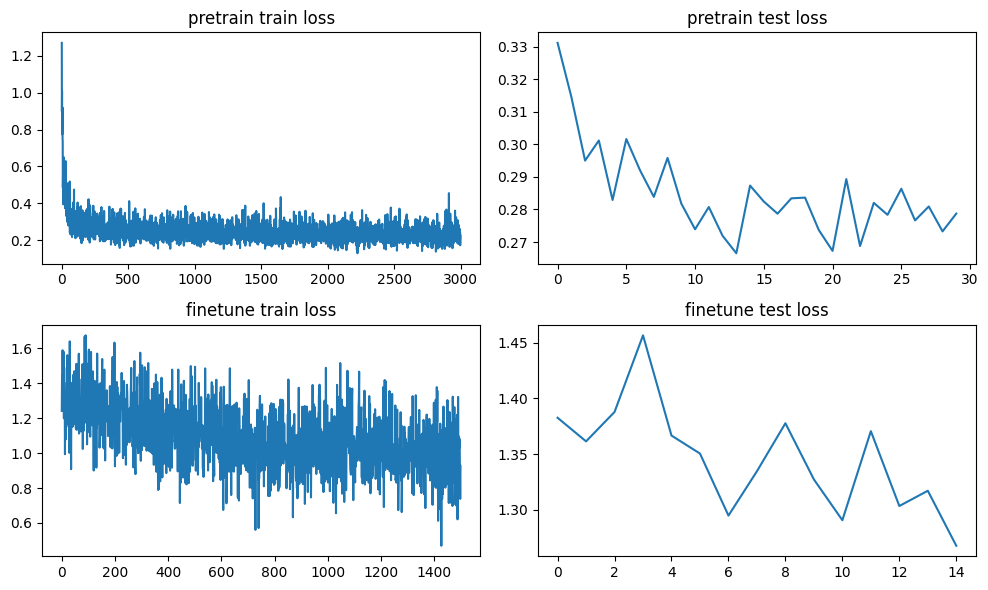

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].plot(last_fold_histories["pretrain_train"]); axes[0, 0].set_title("pretrain train loss")
axes[0, 1].plot(last_fold_histories["pretrain_test"]); axes[0, 1].set_title("pretrain test loss")
axes[1, 0].plot(last_fold_histories["finetune_train"]); axes[1, 0].set_title("finetune train loss")
axes[1, 1].plot(last_fold_histories["finetune_test"]); axes[1, 1].set_title("finetune test loss")
plt.tight_layout()
plt.show()
